In [5]:
import numpy as np
import re
import matplotlib.pyplot as plt

In [6]:
# --- 1. HÀM ĐỌC DỮ LIỆU CHUẨN ---
def parse_vrp_file(content):
    data = {}
    lines = [l.strip() for l in content.split('\n') if l.strip()]
    # Đọc Optimal value
    data['optimal_value'] = None
    for line in lines:
        if "COMMENT" in line:
            # Tìm kiếm mẫu "Optimal value:" theo sau là các chữ số
            match = re.search(r"Optimal value\s*:\s*(\d+)", line)
            if match:
                data['optimal_value'] = int(match.group(1))
            break
    
    # Đọc Capacity
    for line in lines:
        if "CAPACITY" in line:
            data['capacity'] = int(line.split(':')[-1])
            break
            
    # Đọc Tọa độ
    coord_start = lines.index("NODE_COORD_SECTION") + 1
    demands_start = lines.index("DEMAND_SECTION") + 1
    
    coords = []
    for i in range(coord_start, demands_start - 1):
        parts = lines[i].split()
        coords.append([float(parts[1]), float(parts[2])])
    
    # Đọc Nhu cầu
    demands = []
    for i in range(demands_start, lines.index("DEPOT_SECTION")):
        parts = lines[i].split()
        demands.append(int(parts[1]))
        
    data['coords'] = np.array(coords)
    data['demands'] = np.array(demands)
    return data

In [7]:
class CVRP_DE_Solver:
    def __init__(self, data, pop_size=50, f_weight=0.5, cr_prob=0.7, gens=1000):
        self.coords = data['coords']
        self.demands = data['demands']
        self.Q = data['capacity']
        self.n_customers = len(self.demands) - 1
        self.pop_size = pop_size
        self.F = f_weight  # Hệ số đột biến (Mutation scale factor)
        self.CR = cr_prob  # Xác suất lai ghép (Crossover probability)
        self.gens = gens
        self.depot = self.coords[0]

    def fitness(self, random_keys):
        """Giải mã Random Keys thành hoán vị và tính tổng quãng đường"""
        # 1. Giải mã: Sắp xếp chỉ số dựa trên giá trị Random Keys
        tour = np.argsort(random_keys) + 1 # +1 vì bỏ qua Depot ở index 0
        
        dist = 0
        load = 0
        curr_pos = self.depot
        
        for i in tour:
            d = self.demands[i]
            loc = self.coords[i]
            if load + d > self.Q:
                dist += np.linalg.norm(curr_pos - self.depot)
                dist += np.linalg.norm(self.depot - loc)
                load = d
            else:
                dist += np.linalg.norm(curr_pos - loc)
                load += d
            curr_pos = loc
            
        dist += np.linalg.norm(curr_pos - self.depot)
        return dist

    def run(self):
        # Khởi tạo quần thể: Mỗi cá thể là một vector số thực [0, 1]
        pop = np.random.rand(self.pop_size, self.n_customers)
        fitness_values = np.array([self.fitness(ind) for ind in pop])
        
        history = []
        
        for g in range(self.gens):
            for i in range(self.pop_size):
                # 1. Đột biến (Mutation): Chọn 3 cá thể ngẫu nhiên r1, r2, r3 khác i
                idxs = [idx for idx in range(self.pop_size) if idx != i]
                r1, r2, r3 = pop[np.random.choice(idxs, 3, replace=False)]
                
                # Tạo vector đột biến (Donor vector): V = r1 + F * (r2 - r3)
                v_donor = r1 + self.F * (r2 - r3)
                v_donor = np.clip(v_donor, 0, 1) # Giữ giá trị trong [0, 1]
                
                # 2. Lai ghép (Crossover): Kết hợp cá thể hiện tại với vector đột biến
                trial = np.copy(pop[i])
                j_rand = np.random.randint(self.n_customers)
                for j in range(self.n_customers):
                    if np.random.rand() < self.CR or j == j_rand:
                        trial[j] = v_donor[j]
                
                # 3. Chọn lọc (Selection): So sánh trial với cá thể hiện tại
                f_trial = self.fitness(trial)
                if f_trial < fitness_values[i]:
                    pop[i] = trial
                    fitness_values[i] = f_trial
            
            best_idx = np.argmin(fitness_values)
            history.append(fitness_values[best_idx])
            if g % 50 == 0: print(f"Gen {g}: Best Dist = {fitness_values[best_idx]:.2f}")
            
        return np.argsort(pop[best_idx]) + 1, history

Gen 0: Best Dist = 1716.07
Gen 50: Best Dist = 1370.18
Gen 100: Best Dist = 1370.18
Gen 150: Best Dist = 1324.69
Gen 200: Best Dist = 1290.69
Gen 250: Best Dist = 1224.80
Gen 300: Best Dist = 1192.48
Gen 350: Best Dist = 1137.25
Gen 400: Best Dist = 1114.94
Gen 450: Best Dist = 1007.31
Gen 500: Best Dist = 1003.22
Gen 550: Best Dist = 946.36
Gen 600: Best Dist = 898.74
Gen 650: Best Dist = 898.74
Gen 700: Best Dist = 898.74
Gen 750: Best Dist = 898.74
Gen 800: Best Dist = 888.49
Gen 850: Best Dist = 888.49
Gen 900: Best Dist = 858.88
Gen 950: Best Dist = 840.11
Kết quả tốt nhất tìm được: 840.11
Độ lệch so với tối ưu (784): 7.16%


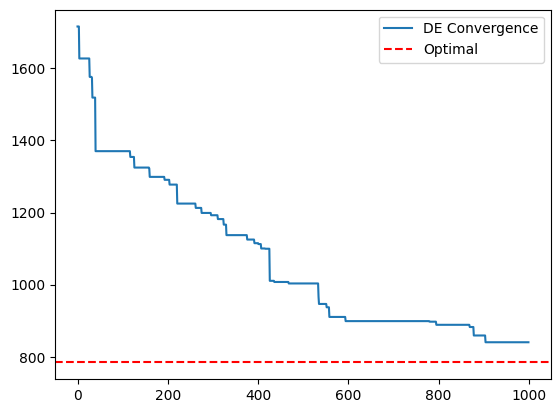

In [8]:
file_path = "./Data/A-n32-k5.vrp"

# Mở và đọc nội dung file
with open(file_path, 'r') as f:
    file_content = f.read()

data = parse_vrp_file(file_content)
opt_val = data['optimal_value']

solver_de = CVRP_DE_Solver(data)
best_tour_de, history_de = solver_de.run()

print(f"Kết quả tốt nhất tìm được: {history_de[-1]:.2f}")
print(f"Độ lệch so với tối ưu ({opt_val}): {((history_de[-1]-opt_val)/opt_val)*100:.2f}%")

plt.plot(history_de, label='DE Convergence')
plt.axhline(y=opt_val, color='r', linestyle='--', label='Optimal')
plt.legend()
plt.show()